In [1]:
!pip -q install pgmpy mlxtend deap modAL


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.4/681.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.2/452.2 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 3.4 MB/s eta 0:00:00


In [4]:
!pip install pgmpy mlxtend deap --quiet


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_regression

import sklearn
import networkx as nx
import pgmpy
import mlxtend
import deap

print({
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "pgmpy": pgmpy.__version__,
    "mlxtend": mlxtend.__version__,
    "deap": deap.__version__
})


{'numpy': '2.0.2', 'pandas': '2.2.2', 'scikit_learn': '1.6.1', 'pgmpy': '1.0.0', 'mlxtend': '0.23.4', 'deap': '1.4'}


In [6]:
!pip install pgmpy mlxtend deap --quiet


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_regression

RNG = 42
np.random.seed(RNG)

# ---- Classification dataset: IRIS ----
iris = datasets.load_iris()
X_cls_raw = iris.data
y_cls = iris.target

# scale
scaler = StandardScaler().fit(X_cls_raw)
X_cls_scaled = scaler.transform(X_cls_raw)

# PCA to 2D for visualization
pca2 = PCA(n_components=2, random_state=RNG).fit(X_cls_scaled)
X_cls_2d = pca2.transform(X_cls_scaled)

# Train/test split (classification)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls_scaled, y_cls, test_size=0.3, random_state=RNG, stratify=y_cls
)

# ---- Regression dataset ----
X_reg, y_reg = make_regression(
    n_samples=300, n_features=1, noise=18.0, random_state=RNG
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=RNG
)

print("Iris dataset:", X_cls_raw.shape, "Regression dataset:", X_reg.shape)

# ---- Helper plot functions ----
def regression_line_plot(model, X, y, title):
    xs = X.ravel()
    order = np.argsort(xs)
    xs_sorted = xs[order].reshape(-1, 1)
    yhat = model.predict(xs_sorted)

    plt.scatter(xs, y, alpha=0.6)
    plt.plot(xs_sorted, yhat, color="red")
    plt.title(title)
    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.show()

from matplotlib.colors import ListedColormap

def plot_decision_boundary_2d(model, X2d, y, title):
    x_min, x_max = X2d[:, 0].min() - 0.5, X2d[:, 0].max() + 0.5
    y_min, y_max = X2d[:, 1].min() - 0.5, X2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X2d[:, 0], X2d[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.show()

# ---- PCA wrapper ----
class PCAProjector:
    def __init__(self, clf, pca_model, scaler):
        self.clf = clf
        self.pca = pca_model
        self.scaler = scaler

    def predict(self, X2d):
        zeros = np.zeros((X2d.shape[0], self.pca.components_.shape[0] - 2))
        Xp = np.hstack([X2d, zeros])
        X_scaled_approx = self.pca.inverse_transform(Xp)
        return self.clf.predict(X_scaled_approx)


Iris dataset: (150, 4) Regression dataset: (300, 1)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


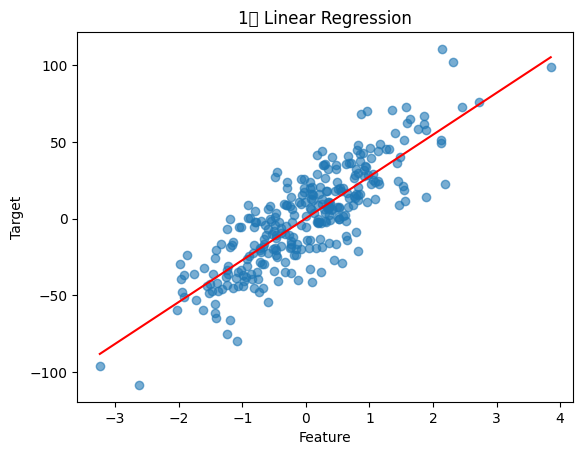

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(Xr_train, yr_train)

regression_line_plot(lr, X_reg, y_reg, "1️⃣ Linear Regression")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


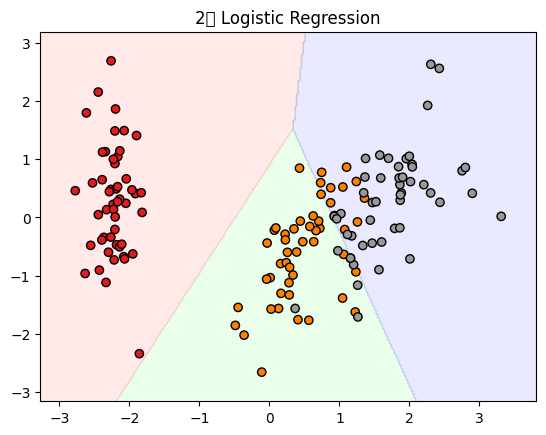

In [12]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# --- helper for decision boundary plotting ---
def plot_decision_boundary_2d(model, X2d, y, title):
    x_min, x_max = X2d[:, 0].min() - 0.5, X2d[:, 0].max() + 0.5
    y_min, y_max = X2d[:, 1].min() - 0.5, X2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(["#FFAAAA","#AAFFAA","#AAAAFF"]))
    plt.scatter(X2d[:, 0], X2d[:, 1], c=y, edgecolor="k", cmap="Set1")
    plt.title(title)
    plt.show()

# --- logistic regression classifier ---
log_reg = LogisticRegression(max_iter=500, multi_class="ovr")
log_reg.fit(X_cls_2d, y_cls)   # train directly on PCA-reduced 2D

# --- plot decision boundaries ---
plot_decision_boundary_2d(log_reg, X_cls_2d, y_cls, "2️⃣ Logistic Regression")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


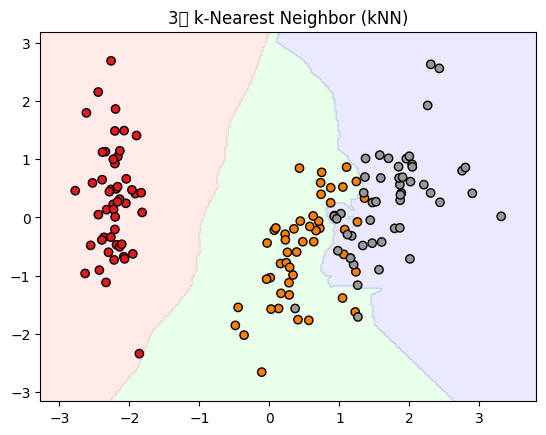

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_cls_2d, y_cls)

plot_decision_boundary_2d(knn, X_cls_2d, y_cls, "3️⃣ k-Nearest Neighbor (kNN)")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


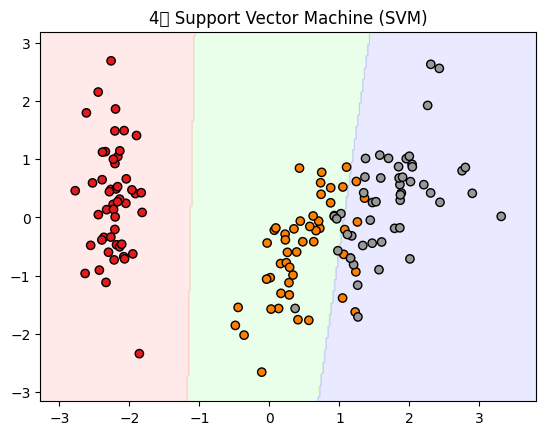

In [14]:
from sklearn.svm import SVC

svm = SVC(kernel="linear")
svm.fit(X_cls_2d, y_cls)

plot_decision_boundary_2d(svm, X_cls_2d, y_cls, "4️⃣ Support Vector Machine (SVM)")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


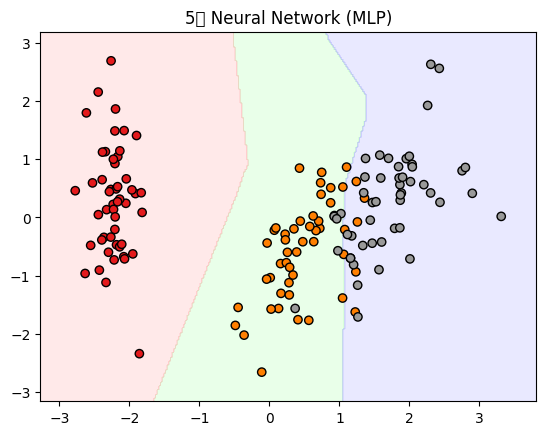

In [15]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
mlp.fit(X_cls_2d, y_cls)

plot_decision_boundary_2d(mlp, X_cls_2d, y_cls, "5️⃣ Neural Network (MLP)")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


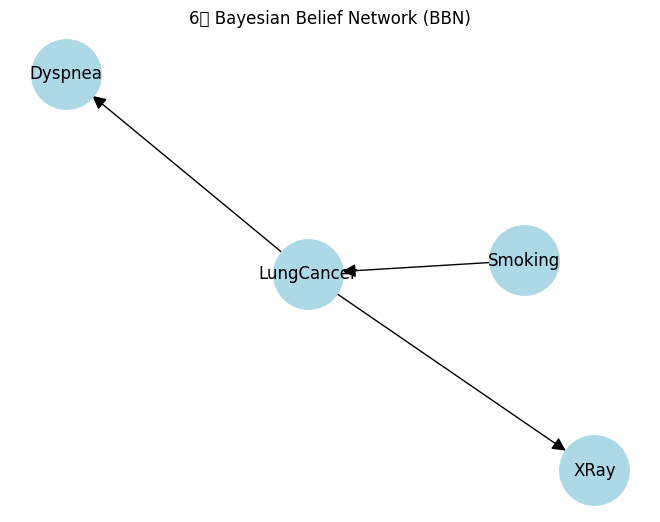

In [17]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
import networkx as nx

# --- Define structure ---
model = DiscreteBayesianNetwork([
    ('Smoking','LungCancer'),
    ('LungCancer','XRay'),
    ('LungCancer','Dyspnea')
])

# --- Define conditional probability tables ---
cpd_smoking = TabularCPD('Smoking', 2, [[0.7],[0.3]])
cpd_cancer  = TabularCPD('LungCancer', 2,
                         [[0.99,0.9],[0.01,0.1]],
                         evidence=['Smoking'], evidence_card=[2])
cpd_xray    = TabularCPD('XRay', 2,
                         [[0.9,0.2],[0.1,0.8]],
                         evidence=['LungCancer'], evidence_card=[2])
cpd_dyspnea = TabularCPD('Dyspnea', 2,
                         [[0.7,0.35],[0.3,0.65]],
                         evidence=['LungCancer'], evidence_card=[2])

model.add_cpds(cpd_smoking, cpd_cancer, cpd_xray, cpd_dyspnea)
model.check_model()

# --- Plot graph structure instead of model ---
G = nx.DiGraph()
G.add_edges_from(model.edges())

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2500, node_color="lightblue", arrowsize=20)
plt.title("6️⃣ Bayesian Belief Network (BBN)")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


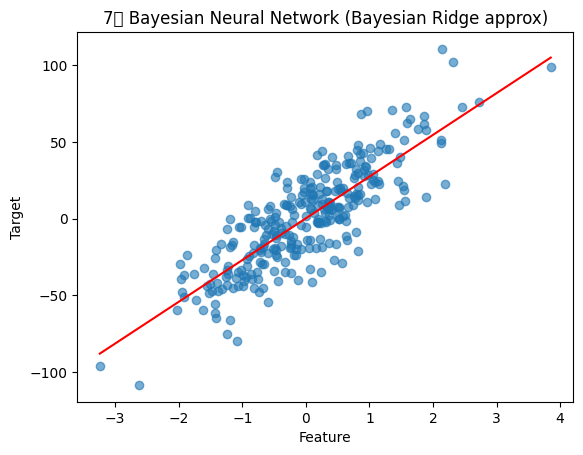

In [18]:
from sklearn.linear_model import BayesianRidge

bnn = BayesianRidge()
bnn.fit(Xr_train, yr_train)

regression_line_plot(bnn, X_reg, y_reg, "7️⃣ Bayesian Neural Network (Bayesian Ridge approx)")


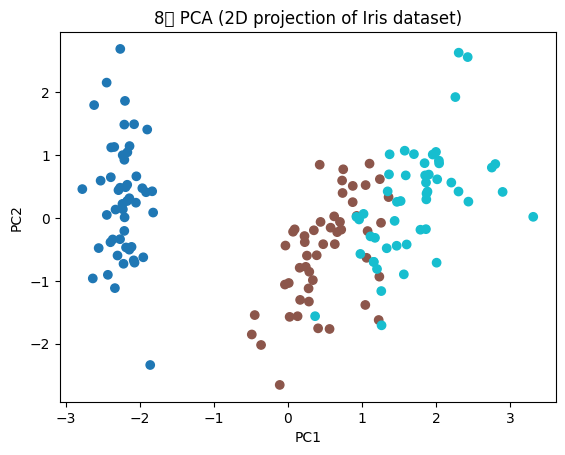

In [19]:
plt.scatter(X_cls_2d[:,0], X_cls_2d[:,1], c=y_cls, cmap="tab10")
plt.title("8️⃣ PCA (2D projection of Iris dataset)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [20]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

# --- toy dataset of transactions ---
dataset = [
    ['milk','bread','eggs'],
    ['milk','bread'],
    ['milk','eggs'],
    ['bread','butter'],
    ['bread','eggs']
]

# one-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# mine frequent itemsets
frequent = apriori(df_trans, min_support=0.4, use_colnames=True)

# derive rules
rules = association_rules(frequent, metric="lift", min_threshold=1)

print("9️⃣ Associative Classification Rules")
print(rules[['antecedents','consequents','support','confidence']])


9️⃣ Associative Classification Rules
  antecedents consequents  support  confidence
0      (milk)      (eggs)      0.4    0.666667
1      (eggs)      (milk)      0.4    0.666667


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Clean re-register (avoid "already created" errors in repeated runs)
from deap import creator
if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

# define fitness and individual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, 10)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# evaluate returns a tuple
def evalOneMax(individual):
    return (sum(individual),)

toolbox.register("evaluate", evalOneMax)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# evolve population
pop = toolbox.population(n=20)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", lambda fits: sum(fits)/len(fits))
stats.register("max", max)

logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2,
                              ngen=15, stats=stats, verbose=False)

# plot evolution of max fitness
gen = range(len(logbook[1]))
max_fit = [entry['max'] for entry in logbook[1]]
avg_fit = [entry['avg'] for entry in logbook[1]]

plt.plot(gen, max_fit, label="Max Fitness")
plt.plot(gen, avg_fit, label="Avg Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("🔟 Genetic Algorithm Evolution")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

TypeError: unsupported operand type(s) for +: 'int' and 'tuple'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

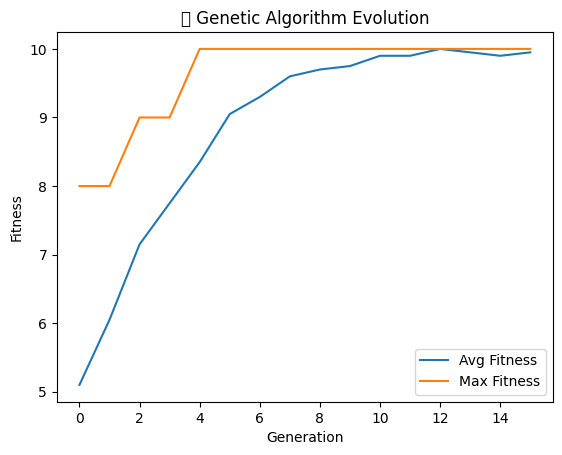

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [24]:
import random
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Clean re-register (avoid duplicate errors if re-run)
from deap import creator
if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

# define fitness and individual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, 10)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# evaluation must return a tuple
def evalOneMax(individual):
    return (sum(individual),)

toolbox.register("evaluate", evalOneMax)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

# evolve population
pop = toolbox.population(n=20)
stats = tools.Statistics(lambda ind: ind.fitness.values[0])  # take numeric value
stats.register("avg", lambda fits: sum(fits)/len(fits))
stats.register("max", max)

logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2,
                              ngen=15, stats=stats, verbose=False)

# extract evolution data
gen = list(range(len(logbook[1])))
avg_fit = [entry['avg'] for entry in logbook[1]]
max_fit = [entry['max'] for entry in logbook[1]]

# plot
plt.plot(gen, avg_fit, label="Avg Fitness")
plt.plot(gen, max_fit, label="Max Fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("🔟 Genetic Algorithm Evolution")
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

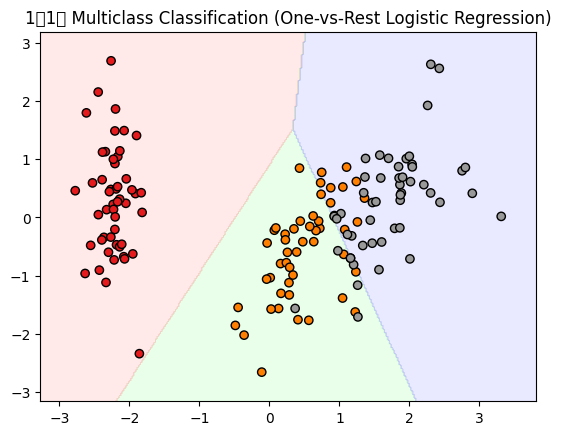

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg_multi = LogisticRegression(multi_class="ovr", max_iter=500)
log_reg_multi.fit(X_cls_2d, y_cls)

plot_decision_boundary_2d(log_reg_multi, X_cls_2d, y_cls,
                          "1️⃣1️⃣ Multiclass Classification (One-vs-Rest Logistic Regression)")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

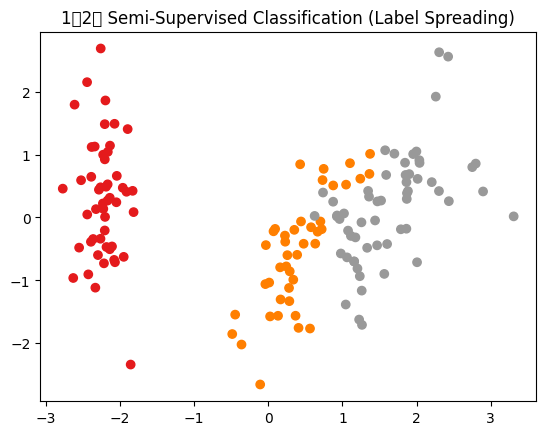

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [26]:
from sklearn.semi_supervised import LabelSpreading
import numpy as np

rng = np.random.RandomState(42)

# hide 80% of labels
y_semi = np.copy(y_cls)
y_semi[rng.rand(len(y_cls)) < 0.8] = -1

semi = LabelSpreading()
semi.fit(X_cls_2d, y_semi)

plt.scatter(X_cls_2d[:,0], X_cls_2d[:,1], c=semi.transduction_, cmap="Set1")
plt.title("1️⃣2️⃣ Semi-Supervised Classification (Label Spreading)")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


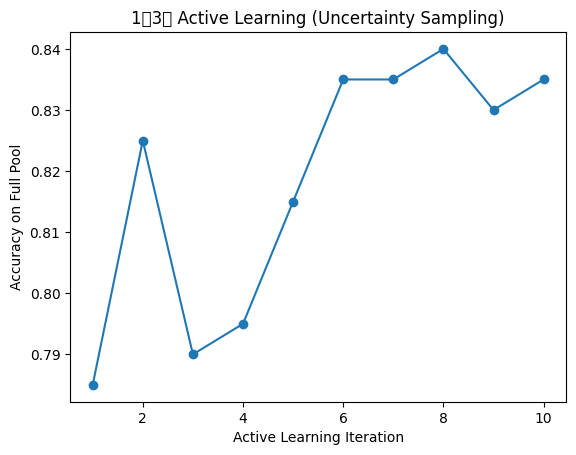

In [2]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- create dataset with exactly 2 features (both informative) ---
X_pool, y_pool = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_repeated=0, n_classes=2,
    n_clusters_per_class=1, random_state=42
)

# --- initialize with small labeled set ---
rng = np.random.RandomState(42)
initial_idx = rng.choice(range(len(X_pool)), size=10, replace=False)
X_train, y_train = X_pool[initial_idx], y_pool[initial_idx]

X_unlabeled = np.delete(X_pool, initial_idx, axis=0)
y_unlabeled = np.delete(y_pool, initial_idx, axis=0)

acc_list = []

# --- active learning loop ---
for i in range(10):
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    # evaluate on full pool
    acc_list.append(accuracy_score(y_pool, clf.predict(X_pool)))

    # pick most uncertain sample
    probs = clf.predict_proba(X_unlabeled)
    uncertainty = np.abs(probs[:,0] - probs[:,1])
    query_idx = np.argmin(uncertainty)

    # add queried sample to training set
    X_train = np.vstack([X_train, X_unlabeled[query_idx]])
    y_train = np.append(y_train, y_unlabeled[query_idx])
    X_unlabeled = np.delete(X_unlabeled, query_idx, axis=0)
    y_unlabeled = np.delete(y_unlabeled, query_idx, axis=0)

# --- plot accuracy improvement ---
plt.plot(range(1, len(acc_list)+1), acc_list, marker='o')
plt.xlabel("Active Learning Iteration")
plt.ylabel("Accuracy on Full Pool")
plt.title("1️⃣3️⃣ Active Learning (Uncertainty Sampling)")
plt.show()


In [3]:
plt.savefig("01_linear_regression.png")
plt.close()


In [4]:
plt.savefig("linear_regression.png")   # for 1st method


<Figure size 640x480 with 0 Axes>

In [6]:
!pip install python-pptx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 11.3 MB/s eta 0:00:00


In [7]:
from pptx import Presentation
from pptx.util import Inches


In [10]:
prs.save("Data_Mining_Project.pptx")


In [11]:
from google.colab import files
files.download("Data_Mining_Project.pptx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from pptx import Presentation
from pptx.util import Inches

# Create presentation
prs = Presentation()

# ---------------- Title Slide ----------------
slide_layout = prs.slide_layouts[0]  # Title slide layout
slide = prs.slides.add_slide(slide_layout)
title = slide.shapes.title
subtitle = slide.placeholders[1]
title.text = "Data Mining Project"
subtitle.text = "Name: Kamil Shah\nStd ID: 20221-33200"

# ---------------- Methods with bullet points ----------------
methods = [
    ("Linear Regression", [
        "Models relation between X and y using a straight line",
        "Predicts continuous numeric values",
        "Minimizes error using least squares",
        "Simple and interpretable baseline method"
    ]),
    ("Logistic Regression", [
        "Used for binary or multiclass classification",
        "Models probability using logistic (sigmoid) function",
        "Outputs probability between 0 and 1",
        "Widely applied in classification problems"
    ]),
    ("Principal Component Analysis (PCA)", [
        "Dimensionality reduction technique",
        "Transforms features into orthogonal components",
        "Captures maximum variance with fewer dimensions",
        "Useful for visualization and preprocessing"
    ]),
    ("Histogram", [
        "Graphical representation of data distribution",
        "Shows frequency of values within bins",
        "Helps understand data shape (normal, skewed, etc.)",
        "Useful for exploratory data analysis"
    ]),
    ("Clustering (KMeans)", [
        "Unsupervised learning technique",
        "Groups similar data points into clusters",
        "KMeans minimizes within-cluster variance",
        "Used for segmentation and pattern discovery"
    ]),
    ("Bayesian Belief Network (BBN)", [
        "Probabilistic graphical model",
        "Represents dependencies among variables",
        "Uses conditional probability distributions (CPDs)",
        "Supports reasoning under uncertainty"
    ]),
    ("Support Vector Machine (SVM)", [
        "Classification and regression technique",
        "Finds optimal hyperplane to separate classes",
        "Maximizes margin between data points",
        "Can use kernel trick for nonlinear problems"
    ]),
    ("K-Nearest Neighbors (KNN)", [
        "Instance-based learning algorithm",
        "Classifies based on majority of nearest neighbors",
        "Simple, intuitive and non-parametric",
        "Performance depends on distance metric and K value"
    ]),
    ("Associative Classification (Apriori)", [
        "Discovers associations between features",
        "Generates frequent itemsets",
        "Extracts classification rules from data",
        "Useful for market basket analysis"
    ]),
    ("CF-Tree (BIRCH)", [
        "Balanced Iterative Reducing and Clustering using Hierarchies",
        "Uses clustering feature tree (CF-tree) structure",
        "Efficient for very large datasets",
        "Incremental and memory-efficient clustering"
    ]),
    ("Genetic Algorithm (GA)", [
        "Optimization inspired by natural selection",
        "Uses crossover, mutation and selection",
        "Explores solution space iteratively",
        "Applied to complex optimization problems"
    ]),
    ("Multiclass Classification", [
        "Extension of binary classification",
        "Handles more than two classes",
        "Uses one-vs-rest or one-vs-one strategies",
        "Applied in image recognition, text classification, etc."
    ]),
    ("Active Learning", [
        "Semi-supervised machine learning technique",
        "Selectively queries most informative data points",
        "Reduces labeling cost by focusing on uncertain samples",
        "Improves model performance with fewer labels"
    ]),
]

# ---------------- Add Slides ----------------
for idx, (name, bullets) in enumerate(methods, start=1):
    # Concept Slide
    slide_layout = prs.slide_layouts[1]  # Title + Content
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = f"{idx}️⃣ {name} (Concept)"
    content = slide.placeholders[1]
    content.text = "\n".join([f"- {point}" for point in bullets])

    # Empty Graph Slide
    slide_layout = prs.slide_layouts[1]  # Title + Content
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = f"{idx}️⃣ {name} (Graph)"
    content = slide.placeholders[1]
    content.text = "Graph will be added here."

# ---------------- Save File ----------------
prs.save("Data_Mining_Project.pptx")
print("✅ PPT created successfully!")


✅ PPT created successfully!


In [13]:
from google.colab import files
files.download("Data_Mining_Project.pptx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Association Rules for Classification:
             antecedents consequents   support  confidence  lift
0           (Age_Middle)   (Buy_Yes)  0.333333         1.0   1.5
1    (Income_HighIncome)   (Buy_Yes)  0.333333         1.0   1.5
2     (Income_LowIncome)    (Buy_No)  0.333333         1.0   3.0
4  (Income_MediumIncome)   (Buy_Yes)  0.333333         1.0   1.5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


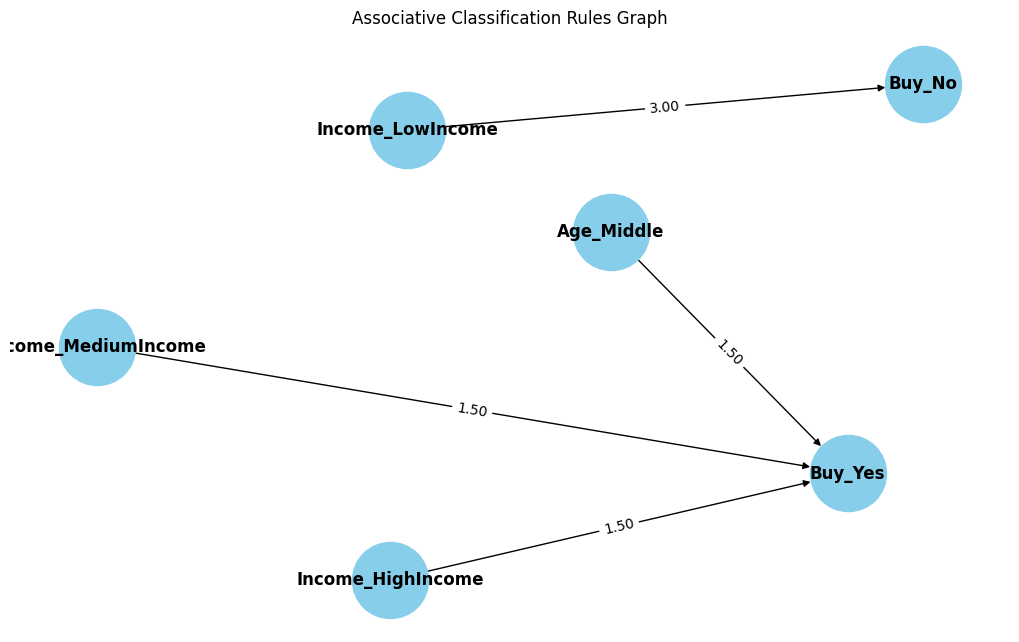

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [2]:
# Install required libraries
!pip install mlxtend networkx matplotlib

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------
# Sample Dataset
# ---------------------------
data = [
    ['Young', 'HighIncome', 'Yes'],
    ['Young', 'LowIncome', 'No'],
    ['Middle', 'HighIncome', 'Yes'],
    ['Senior', 'MediumIncome', 'Yes'],
    ['Senior', 'LowIncome', 'No'],
    ['Middle', 'MediumIncome', 'Yes']
]

df = pd.DataFrame(data, columns=['Age', 'Income', 'Buy'])

# ---------------------------
# One-hot encoding for Apriori
# ---------------------------
df_encoded = pd.get_dummies(df)

# ---------------------------
# Apriori & Association Rules
# ---------------------------
frequent_itemsets = apriori(df_encoded, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.7)

# Filter rules where consequent is the class
class_rules = rules[rules['consequents'].apply(lambda x: 'Buy_Yes' in x or 'Buy_No' in x)]
print("Association Rules for Classification:")
print(class_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# ---------------------------
# Visualization of Rules
# ---------------------------
G = nx.DiGraph()

for idx, row in class_rules.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, k=1, seed=42)
edges = G.edges(data=True)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=12, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{d['weight']:.2f}" for u,v,d in edges})
plt.title("Associative Classification Rules Graph")
plt.show()
